In [33]:
#Imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
#Datasets (Train/Test/Val)

transform = transforms.Compose([
    transforms.ToTensor(),
])

# Dataset completo de treino (60k)
full_train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

# Dataset de teste (10k)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# Divisão treino / validação (80/20)
train_size = int(0.8 * len(full_train_dataset))  
val_size = len(full_train_dataset) - train_size  

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size]
)

In [ ]:
# DataLoaders

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
#CNN model

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3), 
            nn.ReLU(),
            nn.MaxPool2d(2),                

            nn.Conv2d(32, 64, kernel_size=3), 
            nn.ReLU(),
            nn.MaxPool2d(2)               
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [ ]:
#Model Config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#Train and Val

epochs = 5
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    
    # Train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total

    # Val
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss/len(val_loader):.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1 | Train Loss: 0.2235 | Train Acc: 93.18% | Val Loss: 0.1040 | Val Acc: 96.73%
Epoch 2 | Train Loss: 0.0619 | Train Acc: 98.07% | Val Loss: 0.0602 | Val Acc: 98.18%
Epoch 3 | Train Loss: 0.0422 | Train Acc: 98.66% | Val Loss: 0.0478 | Val Acc: 98.67%
Epoch 4 | Train Loss: 0.0317 | Train Acc: 99.02% | Val Loss: 0.0455 | Val Acc: 98.58%
Epoch 5 | Train Loss: 0.0252 | Train Acc: 99.20% | Val Loss: 0.0399 | Val Acc: 98.87%


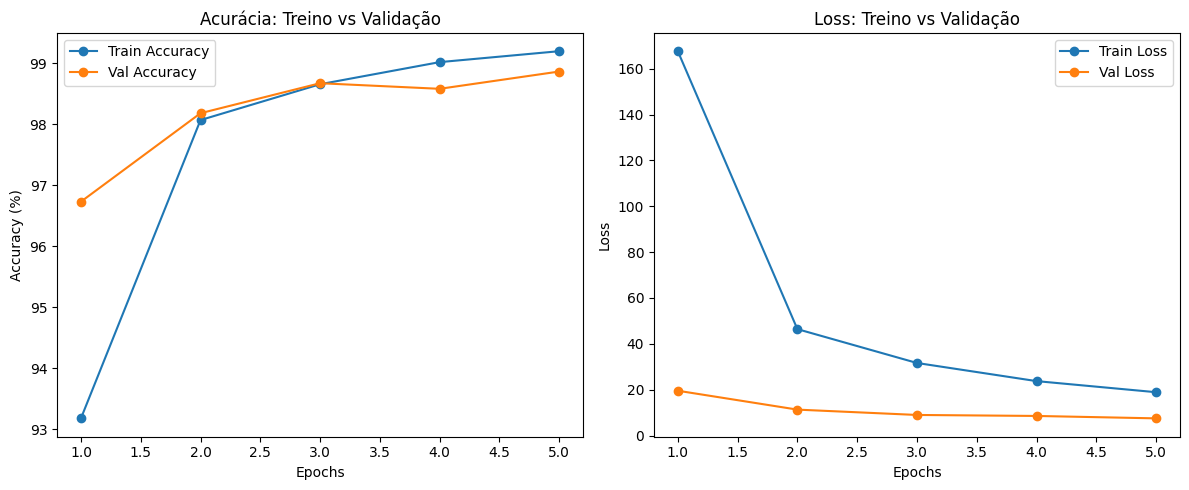

In [ ]:
#Train and val (Acc and Loss)

epochs_range = range(1, epochs + 1)

# Acc
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_accuracies, label='Val Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Acurácia: Treino vs Validação')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Val Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss: Treino vs Validação')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Test

model.eval()
all_labels = []
all_preds = []
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

print(f"Acc no teste: {100 * correct / total:.2f}%")

Acurácia no teste: 99.01%


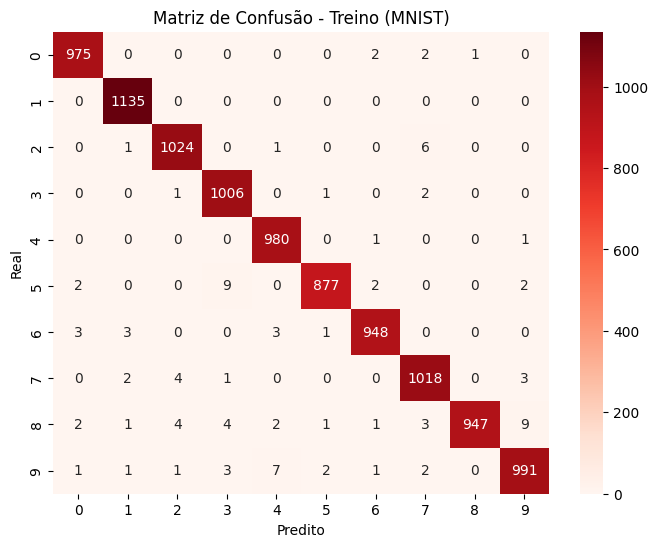

In [ ]:
# Confusion Matrix

cm = confusion_matrix(all_labels, all_preds)


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Treino (MNIST)')

plt.show()

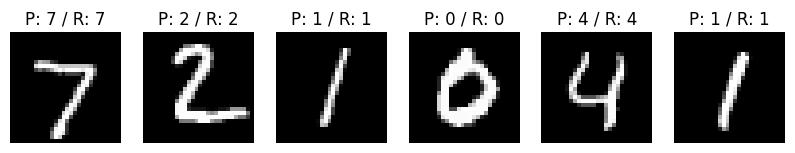

In [ ]:
# Classifying some examples

model.eval()

data_iter = iter(test_loader)
images, labels = next(data_iter)

images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

# Graphic
fig, axes = plt.subplots(1, 6, figsize=(10, 3))
for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"P: {preds[i].item()} / R: {labels[i].item()}")
    axes[i].axis('off')
plt.show()